In [37]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/aangphurbasherpa/Desktop/NYC Taxi Duration/data/processed/NYC_ride_cleaned.csv")
df.head(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,7.583333
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,11.050000
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,35.400000
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,7.150000
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,7.250000


In [4]:
def haversine_form(lat1,long1,lat2,long2):
    lat1 , long1,lat2,long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2-lat1
    dlong = long2-long1
    a  = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2)*np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 3956
    return c*r

In [5]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df.drop(['vendor_id','dropoff_datetime','store_and_fwd_flag'],axis =1,inplace=True)
df['distance'] =  haversine_form(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])
df['day_of_week'] = df['pickup_datetime'].dt.day_of_week
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['is_rush_hour'] = df['pickup_hour'].isin([7,8,9,16,17,18,19]).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [14]:
X = df.drop(['trip_duration','id','pickup_datetime'],axis=1)
y = df['trip_duration']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

In [49]:
models = {"Linear":LinearRegression(),
          "Hist":HistGradientBoostingRegressor(learning_rate=1.0,max_depth=2,random_state=42)
          ,"xgboost":xgb.XGBRegressor(objective='reg:absoluteerror',max_depth=2,n_estimators=200,learning_rate=1.0,random_state=42,n_jobs=-1)}
result = {}
for i in models:
    models[i].fit(X_train,y_train)
    prediction = models[i].predict(X_test)
    mae = round(mean_absolute_error(y_test,prediction),2)
    result[i]=mae

In [41]:
result.keys()

dict_keys(['Linear', 'Hist', 'xgboost'])

Text(0.5, 1.0, 'MAE of models')

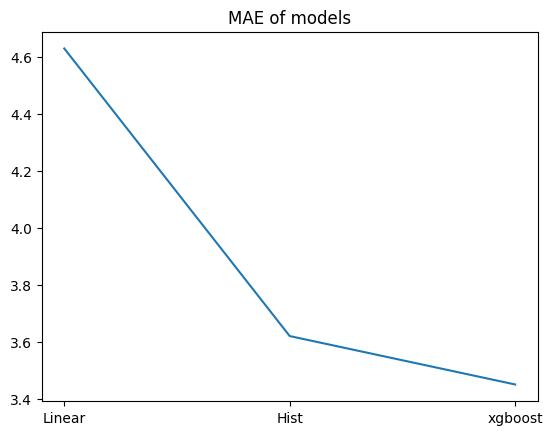

In [50]:
sns.lineplot(result)
plt.title("MAE of models")


In [45]:
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor([
    ('xgb', xgb.XGBRegressor(objective= "reg:absoluteerror",max_depth=2,learning_rate=1.0,n_estimators =200,n_jobs=-1, random_state=42)),
    ('lr',LinearRegression()),
    ('hgb', HistGradientBoostingRegressor(max_depth=2,learning_rate=1.0))
])
ensemble.fit(X_train, y_train)
pred = ensemble.predict(X_test)
print(f"MAE {mean_absolute_error(y_test, pred):.2f}")
print(f"R2 {r2_score(y_test, pred):.2f}")

MAE 3.64
R2 0.73
